In [1]:
#!/usr/bin/env python
# coding: utf-8

import pandas as pd
import numpy as np

def process_fimo(tissue):
    # File path setup
    file_path = f'fimo_out/{tissue}_fimo.tsv.gz'

    # Load data
    df = pd.read_csv(file_path, header=0, sep='\t')

    # Filter for strand '+'
    df = df[df.strand == '+']

    # Create sequence type and SNP columns
    df['seq_type'] = df['sequence_name'].str[-3:]
    df['snp'] = df['sequence_name'].str[:-4]
    
    # Create snp_id
    df['snp_id'] = df['sequence_name'].str[:-4] + ':' + df['motif_alt_id']

    # Extract unique SNP IDs
    all_ids = np.unique(df.snp_id)

    # Split data by seq_type
    df_ref = df[df.seq_type == 'ref']
    df_alt = df[df.seq_type == 'alt']

    # Create dictionaries for p-values
    dict_ref = {row.snp_id: row['p-value'] for i, row in df_ref.iterrows()}
    dict_alt = {row.snp_id: row['p-value'] for i, row in df_alt.iterrows()}

    # Get ref and alt p-values
    ref_pval = [dict_ref.get(id, 1) for id in all_ids]
    alt_pval = [dict_alt.get(id, 1) for id in all_ids]

    # Create new DataFrame with ref, alt, min, and max p-values
    df2 = pd.DataFrame({'id': all_ids, 'ref_pval': ref_pval, 'alt_pval': alt_pval})
    df2['min_pval'] = df2[['ref_pval', 'alt_pval']].min(axis=1)
    df2['max_pval'] = df2[['ref_pval', 'alt_pval']].max(axis=1)

    # Filter by minimum p-value
    df2 = df2[df2.min_pval < 1e-4]

    # Calculate odd ratios
    df2['odd'] = df2.max_pval / df2.min_pval

    # Filter based on odd ratio
    x = df2['odd'] > 10
    #odd_ratio_count = sum(x)

    # Extract SNP and motif columns
    df2['snp'] = df2['id'].str.split(':').str[0]
    df2['motif'] = df2['id'].str.split(':').str[1]

    
    n1 = len(df['snp'].unique())
    n2 = len(df2['snp'].unique())
    
    print(f'#SNP tested: {n1}')
    print(f'# disruptive SNP: {n2}')
    print(f'# disruptive SNP ratio: {n2/n1}')  

    # Return results
    return df2




In [2]:
tissue = 'brain'
df_brain = process_fimo(tissue)

#SNP tested: 3460
# disruptive SNP: 2008
# disruptive SNP ratio: 0.5803468208092486


In [3]:
tissue = 'liver'
df_liver = process_fimo(tissue)

#SNP tested: 1888
# disruptive SNP: 1081
# disruptive SNP ratio: 0.5725635593220338


In [4]:
tissue = 'gonad'
df_gonad = process_fimo(tissue)

#SNP tested: 1647
# disruptive SNP: 956
# disruptive SNP ratio: 0.5804493017607771


In [5]:
tissue = 'muscle'
df_muscle = process_fimo(tissue)

#SNP tested: 1066
# disruptive SNP: 625
# disruptive SNP ratio: 0.5863039399624765


In [6]:
df_brain.to_csv('fimo_out/disrupted_TF_brain.csv', index=False)

df_gonad.to_csv('fimo_out/disrupted_TF_gonad.csv', index=False)

df_liver.to_csv('fimo_out/disrupted_TF_liver.csv', index=False)

df_muscle.to_csv('fimo_out/disrupted_TF_muscle.csv', index=False)


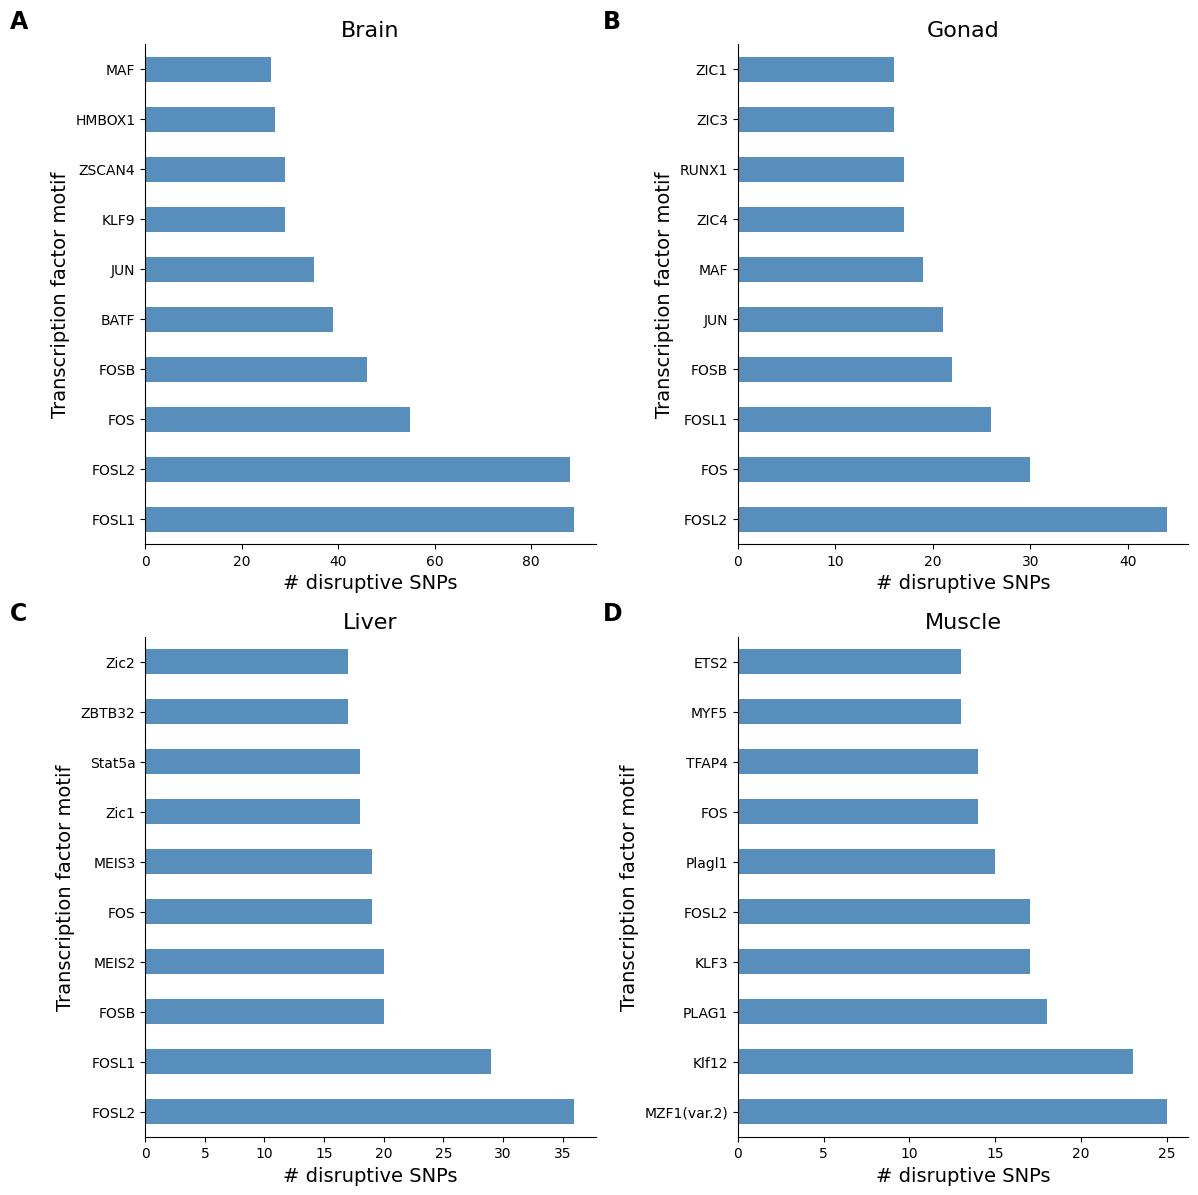

In [7]:
import matplotlib.pyplot as plt

# Function to plot top 10 motifs with larger bars and no top/right spines
def plot_top_motifs(ax, df, title, annotation):
    top_10_motifs = df['motif'].value_counts().head(10)
    top_10_motifs.plot(kind='barh', ax=ax, color='steelblue', alpha=0.9)  # Horizontal bars
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('# disruptive SNPs', fontsize=14)
    ax.set_ylabel('Transcription factor motif', fontsize=14)
    
    # Add annotation
    ax.text(-0.3, 1.07, annotation, transform=ax.transAxes, fontsize=17, fontweight='bold', va='top', ha='left')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Create a figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Plot top 10 motifs for each dataframe with annotations
plot_top_motifs(axes[0, 0], df_brain, 'Brain', 'A')
plot_top_motifs(axes[0, 1], df_gonad, 'Gonad', 'B')
plot_top_motifs(axes[1, 0], df_liver, 'Liver', 'C')
plot_top_motifs(axes[1, 1], df_muscle, 'Muscle', 'D')

# Adjust layout for better spacing
plt.tight_layout()

plt.savefig('Fig3.pdf', format='pdf')

# Show the plot
plt.show()


In [8]:
# import matplotlib.pyplot as plt

# # Function to plot top 10 motifs with larger bars and no top/right spines
# def plot_top_motifs(ax, df, title):
#     top_10_motifs = df['motif'].value_counts().head(10)
#     top_10_motifs.plot(kind='bar', ax=ax, color='steelblue', alpha = 0.9, width=0.7)  # Adjusted bar width
#     ax.set_title(title, fontsize=16)
#     ax.set_xlabel('Transcription factor motif', fontsize=14)
#     ax.set_ylabel('# disruptive SNPs', fontsize=14)
    
#     # Remove top and right spines
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)



# # Create a figure and subplots
# fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# # Plot top 10 motifs for each dataframe
# plot_top_motifs(axes[0, 0], df_brain, 'Brain')
# plot_top_motifs(axes[0, 1], df_gonad, 'Gonad')
# plot_top_motifs(axes[1, 0], df_liver, 'Liver')
# plot_top_motifs(axes[1, 1], df_muscle, 'Muscle')

# # Adjust layout for better spacing
# plt.tight_layout()

# plt.savefig('Fig3.pdf', format='pdf')

# # Show the plot
# plt.show()
